In [1]:
import pandas as pd
import matplotlib.pyplot as plt
import numpy as np
import sys
sys.path.append("..")  # db_config.py lives in the repo root
from db_config import read_sql


query = """SELECT 
CASE WHEN first_time_home_buyer = 'NaN' Then 'Repeat Buyer' WHEN first_time_home_buyer = 'N' Then 'Repeat Buyer' WHEN first_time_home_buyer = 'Y' Then 'First Time Buyer' END AS New_Buyer,
CASE WHEN down_payment_assistance = 'NaN' Then 'No Assistance' When down_payment_assistance = 'N' Then 'No Assistance' WHEN down_payment_assistance = 'Y' Then 'Received Assistance' END AS Assistance,
CASE WHEN agency = 'F' Then 'FHA' WHEN agency = 'V' Then 'VA' WHEN agency = 'R' Then 'RD' ELSE 'PIH' END AS Insurer,
COUNT(*) AS Total_Loans,
ROUND(AVG(TRY_CAST(loan_interest_rate AS FLOAT)),2) AS Average_Interest_Rate
FROM gnma_static_table
GROUP BY CASE WHEN first_time_home_buyer = 'NaN' Then 'Repeat Buyer' WHEN first_time_home_buyer = 'N' Then 'Repeat Buyer' WHEN first_time_home_buyer = 'Y' Then 'First Time Buyer' END, 
CASE WHEN down_payment_assistance = 'NaN' Then 'No Assistance' When down_payment_assistance = 'N' Then 'No Assistance' WHEN down_payment_assistance = 'Y' Then 'Received Assistance' END, 
CASE WHEN agency = 'F' Then 'FHA' WHEN agency = 'V' Then 'VA' WHEN agency = 'R' Then 'RD' ELSE 'PIH' END"""

df = read_sql(query)


print(df.head())

C:\Users\H59045\AppData\Local\Temp\1\ipykernel_7060\2697735305.py:26: UserWarning: pandas only supports SQLAlchemy connectable (engine/connection) or database string URI or sqlite3 DBAPI2 connection. Other DBAPI2 objects are not tested. Please consider using SQLAlchemy.
  df = pd.read_sql(query, conn)


          new_buyer           assistance insurer  total_loans  \
0  First Time Buyer        No Assistance     FHA      3271835   
1  First Time Buyer        No Assistance     PIH         8563   
2  First Time Buyer        No Assistance      RD       458823   
3  First Time Buyer        No Assistance      VA       959260   
4  First Time Buyer  Received Assistance     FHA       666050   

   average_interest_rate  
0                   4.83  
1                   4.64  
2                   4.31  
3                   4.64  
4                   4.75  


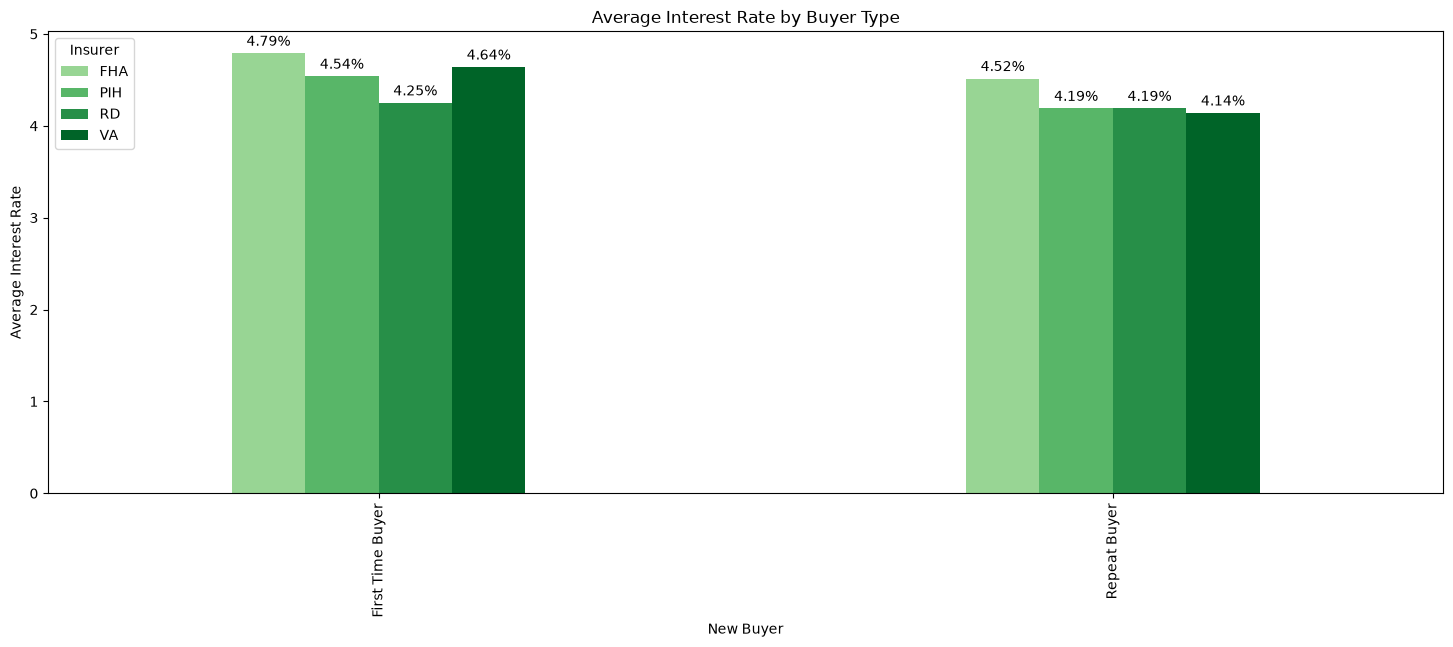

In [3]:
pivot_df = df.pivot_table(index='new_buyer', columns='insurer',values='average_interest_rate')

ax = pivot_df.plot(kind='bar', figsize=(18,6), width=.4, color=plt.cm.Greens(np.linspace(.4,.9,len(pivot_df.columns))))

for container in ax.containers:
    ax.bar_label(container, fmt='%.2f%%', padding=3)

plt.xlabel('New Buyer')
plt.ylabel('Average Interest Rate')
plt.title('Average Interest Rate by Buyer Type')
plt.legend(title='Insurer', loc='upper left')
plt.show()